In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

In [ ]:
import yfinance as yf
dat = yf.Ticker("MSFT")

In [ ]:
dat = yf.Ticker("MSFT")
dat.info
dat.calendar

{'Dividend Date': datetime.date(2026, 9, 10),
 'Ex-Dividend Date': datetime.date(2026, 8, 20),
 'Earnings Date': [datetime.date(2026, 7, 29)],
 'Earnings High': 4.89,
 'Earnings Low': 4.07,
 'Earnings Average': 4.23777,
 'Revenue High': 91239000000,
 'Revenue Low': 86900000000,
 'Revenue Average': 87658501440}

In [ ]:
yf_data = dat.history(period='180mo')

In [ ]:
import pandas as pd

In [ ]:
data = pd.DataFrame(yf_data)
data = data.reset_index()
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2011-07-15 00:00:00-04:00,20.355850,20.709598,20.355850,20.594246,49132400,0.0,0.0
1,2011-07-18 00:00:00-04:00,20.478893,20.686528,20.194358,20.448133,44501900,0.0,0.0
2,2011-07-19 00:00:00-04:00,20.617313,21.255596,20.594243,21.178696,86730600,0.0,0.0
3,2011-07-20 00:00:00-04:00,20.978749,21.032580,20.748043,20.809565,49795400,0.0,0.0
4,2011-07-21 00:00:00-04:00,20.794190,21.001823,20.494272,20.840330,81737400,0.0,0.0
...,...,...,...,...,...,...,...,...
3765,2026-07-08 00:00:00-04:00,384.029999,385.309998,381.329987,383.339996,25908300,0.0,0.0
3766,2026-07-09 00:00:00-04:00,374.450012,384.649994,373.350006,384.359985,31083200,0.0,0.0
3767,2026-07-10 00:00:00-04:00,387.799988,391.910004,381.500000,385.100006,24644600,0.0,0.0
3768,2026-07-13 00:00:00-04:00,387.750000,393.649994,384.149994,390.989990,28914900,0.0,0.0


In [ ]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data = data.where(
    (data['Year'] < 2026) | (data['Month'] < 6)
).dropna()
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Year,Month
0,2011-07-15 00:00:00-04:00,20.355850,20.709598,20.355850,20.594246,49132400.0,0.0,0.0,2011.0,7.0
1,2011-07-18 00:00:00-04:00,20.478893,20.686528,20.194358,20.448133,44501900.0,0.0,0.0,2011.0,7.0
2,2011-07-19 00:00:00-04:00,20.617313,21.255596,20.594243,21.178696,86730600.0,0.0,0.0,2011.0,7.0
3,2011-07-20 00:00:00-04:00,20.978749,21.032580,20.748043,20.809565,49795400.0,0.0,0.0,2011.0,7.0
4,2011-07-21 00:00:00-04:00,20.794190,21.001823,20.494272,20.840330,81737400.0,0.0,0.0,2011.0,7.0
...,...,...,...,...,...,...,...,...,...,...
3735,2026-05-22 00:00:00-04:00,419.540009,424.399994,416.329987,418.570007,22390300.0,0.0,0.0,2026.0,5.0
3736,2026-05-26 00:00:00-04:00,416.429993,419.769989,413.019989,416.029999,30398000.0,0.0,0.0,2026.0,5.0
3737,2026-05-27 00:00:00-04:00,411.010010,415.940002,409.579987,412.670013,28901500.0,0.0,0.0,2026.0,5.0
3738,2026-05-28 00:00:00-04:00,412.980011,429.489990,412.670013,426.989990,47250500.0,0.0,0.0,2026.0,5.0


In [ ]:
# Calculating monthly returns
new_data = pd.DataFrame()
new_data['Month'] = data['Month']
new_data['Year'] = data['Year']
year = 2025
month = 7
# Get first row of each month
year_month = data.groupby([data['Year'], data['Month']])
Open = year_month.first()['Open']
Close = year_month.last()['Close']


In [ ]:
Open = Open.reset_index()

In [ ]:
Close = Close.reset_index()

In [ ]:
new_data = pd.DataFrame()
new_data['Month'] = Open['Month']
new_data['Year'] = Open['Year']
new_data['Open'] = Open['Open']
new_data['Close'] = Close['Close']

In [ ]:
new_data

,Month,Year,Open,Close
0,7.0,2011.0,20.355850,21.071032
1,8.0,2011.0,21.155627,20.584930
2,9.0,2011.0,20.476594,19.261623
3,10.0,2011.0,19.130057,20.608143
4,11.0,2011.0,20.267648,19.944641
...,...,...,...,...
174,1.0,2026.0,482.242449,428.382294
175,2.0,2026.0,428.332518,391.891205
176,3.0,2026.0,392.010924,369.369995
177,4.0,2026.0,372.682807,406.898712


In [ ]:
new_data['Returns'] = (new_data['Close'] - new_data['Open']) / new_data['Open'] * 100

In [ ]:
new_data

,Month,Year,Open,Close,Returns
0,7.0,2011.0,20.355850,21.071032,3.513396
1,8.0,2011.0,21.155627,20.584930,-2.697612
2,9.0,2011.0,20.476594,19.261623,-5.933462
3,10.0,2011.0,19.130057,20.608143,7.726511
4,11.0,2011.0,20.267648,19.944641,-1.593705
...,...,...,...,...,...
174,1.0,2026.0,482.242449,428.382294,-11.168688
175,2.0,2026.0,428.332518,391.891205,-8.507716
176,3.0,2026.0,392.010924,369.369995,-5.775586
177,4.0,2026.0,372.682807,406.898712,9.180972


In [ ]:
new_data

,Month,Year,Open,Close,Returns
0,7.0,2025.0,499.033937,529.272400,6.059400
1,8.0,2025.0,530.760506,503.501221,-5.135892
2,9.0,2025.0,497.320341,514.690369,3.492724
3,10.0,2025.0,511.560137,514.551208,0.584696
4,11.0,2025.0,516.538596,489.828674,-5.170944
5,12.0,2025.0,486.274476,481.475861,-0.986812
6,1.0,2026.0,482.242449,428.382324,-11.168682
7,2.0,2026.0,428.332518,391.891205,-8.507716
8,3.0,2026.0,392.010924,369.369995,-5.775586
9,4.0,2026.0,372.682807,406.898712,9.180972


# S & P Stocks

In [ ]:
import pandas as pd
import yfinance as yf
import requests # Import the requests library


url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Fetch the content using requests and then parse with pandas
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)
df_sp500 = tables[0]


all_tickers = df_sp500['Symbol'].tolist()

all_tickers = [ticker.replace('.', '-') for ticker in all_tickers]

tickers_100 = all_tickers[:100]

# Pulling data for one month

data = yf.download(tickers_100, start="2009-01-01", end="2024-01-01", interval="1mo")
prices = data['Adj Close']

print(prices.head())

/tmp/ipykernel_455/382145963.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_455/382145963.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers_100, start="2009-01-01", end="2024-01-01", interval="1mo")
[*********************100%***********************]  100 of 100 completed


KeyError: 'Adj Close'

In [ ]:
data['Close']

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,CVNA,GOOG,GOOGL,LNT,MMM,MO,SCHW,T,TECH,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-01,11.421566,2.698081,NaN,NaN,18.059574,6.355171,22.707340,19.309999,13.285302,17.187317,...,NaN,8.357957,8.397262,7.801580,26.673405,5.568861,10.855167,5.324667,12.552839,NaN
2009-02-01,8.762005,2.673532,NaN,NaN,15.420996,5.705391,21.002138,16.700001,12.394296,16.817787,...,NaN,8.344625,8.383867,6.259124,22.787792,5.198502,10.198157,5.140835,10.272772,NaN
2009-03-01,9.709596,3.146812,NaN,NaN,15.538263,5.690599,19.778990,21.389999,12.955256,17.524303,...,NaN,8.593242,8.633653,6.681270,24.923214,5.501188,12.436770,5.450107,11.505087,NaN
2009-04-01,11.535276,3.766775,NaN,NaN,13.757615,6.104769,21.174805,27.350000,14.306588,15.530901,...,NaN,9.776091,9.822064,6.149949,28.873234,5.607640,14.827847,5.656417,12.032917,NaN
2009-05-01,11.516323,4.065531,NaN,NaN,14.812861,6.003339,21.534569,28.180000,16.550791,17.458336,...,NaN,10.300979,10.349421,6.526757,28.872168,5.868622,14.167504,5.473170,12.728802,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,118.336426,185.522827,133.440338,131.550003,97.358475,73.086060,306.547729,559.340027,173.177017,72.186333,...,10.070,136.149597,134.973145,45.702000,82.494263,35.183807,56.922089,12.625940,77.268921,57.650002
2023-09-01,109.295280,169.070953,135.347107,137.210007,91.634285,75.796120,290.773926,509.899994,167.596527,68.654388,...,8.396,130.697693,129.709854,44.135185,72.401932,34.206329,52.832172,12.822287,67.087952,44.259998
2023-10-01,101.239769,168.636475,129.475159,118.290001,89.953369,82.423882,282.453583,532.059998,150.596649,65.149757,...,5.400,124.204910,122.989426,44.860222,70.337051,32.677013,50.079891,13.397838,53.841854,40.250000


In [ ]:
# Return for each month

# Return from one period to the next
simple_return = (data[('Close')] / data[('Close')].shift(1)) - 1

# Or using pct_change()
# simple_return = data[('Close', 'AAPL')].pct_change()

simple_return.dropna(axis = 0)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,CVNA,GOOG,GOOGL,LNT,MMM,MO,SCHW,T,TECH,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-01,0.033598,-0.050497,0.015247,-0.187077,-0.028564,0.004533,-0.026934,-0.007397,0.079237,0.059654,...,-0.070707,0.000597,0.001423,0.017447,0.037507,0.030785,0.051745,-0.063037,-0.031172,-0.091087
2021-06-01,0.070079,0.099109,-0.004947,0.090741,-0.006172,-0.023816,0.044762,0.160649,0.045929,-0.089133,...,0.138557,0.039294,0.036040,-0.024322,-0.021720,-0.014252,-0.014083,-0.022087,0.088031,0.095632
2021-07-01,0.038031,0.064983,0.044003,-0.059619,0.047534,0.001541,0.080690,0.061454,-0.027532,-0.014521,...,0.118415,0.079040,0.103506,0.056851,-0.003474,0.007551,-0.066749,-0.001605,0.071025,0.014192
2021-08-01,0.145141,0.042489,0.038521,0.076245,0.044553,0.053846,0.059431,0.067677,-0.022587,0.010654,...,-0.028143,0.075735,0.074009,0.038613,-0.008656,0.045587,0.074698,-0.022460,0.035759,0.084162
2021-09-01,-0.102240,-0.068037,-0.106889,0.082328,-0.065205,-0.071046,-0.049441,-0.132560,0.027800,0.000167,...,-0.080839,-0.083846,-0.076169,-0.079125,-0.099209,-0.077185,-0.000137,-0.014952,-0.029190,-0.105308
2021-10-01,0.000991,0.058657,0.075927,0.017347,0.095299,0.095338,0.124829,0.129646,0.035885,0.070488,...,0.005439,0.112594,0.107499,0.017756,0.018584,-0.030975,0.126167,-0.040605,0.080649,0.061124
2021-11-01,-0.041844,0.105082,0.005319,0.011016,-0.024207,-0.034433,-0.003874,0.029968,0.038965,-0.026219,...,-0.075071,-0.039243,-0.041531,-0.031466,-0.040610,-0.033326,-0.054458,-0.096199,-0.098002,-0.181415
2021-12-01,0.057985,0.074229,0.174532,-0.035064,0.119027,0.100792,0.159905,-0.153452,-0.021119,0.086481,...,-0.173418,0.015637,0.020821,0.121920,0.044637,0.132739,0.086704,0.077529,0.095990,-0.224740
2022-01-01,-0.126191,-0.015712,0.021495,-0.075200,-0.091164,0.042070,-0.144864,-0.057772,-0.067133,0.109631,...,-0.300833,-0.062075,-0.065919,-0.019065,-0.065361,0.073645,0.042806,0.064659,-0.272413,-0.242833


In [ ]:
# Because of missing values, you need to calculate 12 months shift beforehand
from scipy.stats import spearmanr
import numpy as np

momentum_12mo = data['Close'].shift(2)/data['Close'].shift(12) - 1

# Calculate returns
returns = data['Close'].pct_change()

# Looping through each month
ICs = []
values = []
for date in data['Close'].index:

    momentum_12, imm_returns = momentum_12mo.loc[date], returns.loc[date]
    valid = ~ (momentum_12.isna() | imm_returns.isna())
    momentum_12, imm_returns = momentum_12[valid], imm_returns[valid]
    if valid.sum() > 15:
        corr, _ = spearmanr(momentum_12, imm_returns)
        ICs.append({'date': date, 'IC': corr, 'n_stocks': valid.sum()})
        values.append(float(corr))

ic_df = pd.DataFrame(ICs).set_index('date')
ic_df

,IC,n_stocks
date,,
2010-01-01,-0.345469,84
2010-02-01,0.249914,84
2010-03-01,0.301367,84
2010-04-01,-0.075043,84
2010-05-01,0.005366,84
...,...,...
2023-08-01,0.251209,100
2023-09-01,-0.033927,100
2023-10-01,0.007921,100


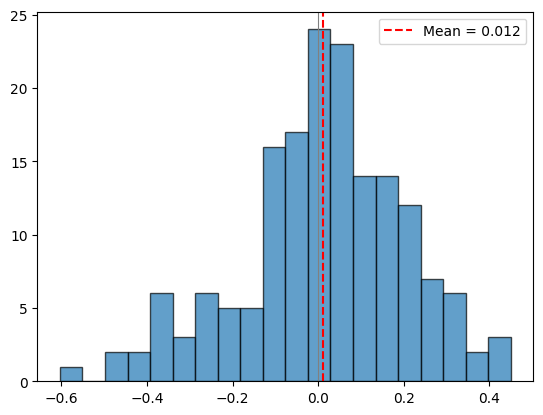

In [ ]:
import matplotlib.pyplot as plt

# (b) Phân phối IC (histogram)
plt.hist(ic_df['IC'], bins=20, color='tab:blue', edgecolor='black', alpha=0.7)
plt.axvline(ic_df['IC'].mean(), color='red', linestyle='--',
                   label=f"Mean = {ic_df['IC'].mean():.3f}")
plt.axvline(0, color='gray', linewidth=0.8)
# plt.set_title('Phân phối IC')
# plt.set_xlabel('IC')
plt.legend()

plt.show()

In [ ]:
values

[-0.34546927204616795,
 0.24991394148020654,
 0.30136681178495495,
 -0.07504302925989674,
 0.005366001822415713,
 -0.0670446491849752,
 0.2111167358509669,
 0.09280828610513973,
 -0.09884698065272621,
 0.04213406292749658,
 0.2969904240766074,
 -0.4203634942349032,
 -0.02501061370819378,
 0.00583989810840134,
 0.11529789140997217,
 0.08071135430916551,
 -0.07354120477381008,
 0.0988007581832762,
 0.017952176131807246,
 -0.1132536268863454,
 -0.05928774513377559,
 -0.2654552744769264,
 0.09134650433768315,
 0.027137858132244654,
 -0.3488736604213749,
 -0.26315885397681704,
 0.04353492303899123,
 0.24044591595928289,
 0.2898101511042232,
 0.05855728928181467,
 0.17229051459969713,
 0.014124194286921916,
 -0.0319115212567363,
 0.06674650417385793,
 0.04312223357167178,
 0.019084099421178075,
 -0.12388491658154584,
 0.13917262512768133,
 -0.0022642151855635007,
 0.058988764044943826,
 0.14203399596658023,
 -0.07042021648763222,
 0.14710458081244596,
 0.04159361238012923,
 0.301494011606371

TypeError: list indices must be integers or slices, not str

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ---- 1. Lấy danh sách ticker + SECTOR từ Wikipedia ----
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

response = requests.get(url, headers=headers)
sp500 = pd.read_html(response.text)[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
# print(sp500[['Symbol', 'GICS Sector']].head())

tickers = sp500['Symbol'].tolist()[:500]
# Series map: ticker -> GICS Sector
sector_map = sp500.set_index('Symbol')['GICS Sector'].loc[tickers]

# ---- 2. Pull giá close hàng tháng ----
data = yf.download(tickers, start='2010-01-01', end='2024-12-31', interval='1mo')['Close']

# ---- 3. Momentum 12-1 và return ----
momentum_12mo = (data.shift(2) / data.shift(12)) - 1
returns = data.pct_change()

# ---- 4. Hàm neutralize theo ngành (trừ mean ngành từng tháng) ----
def sector_neutralize(row, sector_map):
    df = pd.DataFrame({'val': row, 'sector': sector_map})
    return df['val'] - df.groupby('sector')['val'].transform('mean')

momentum_neutral = momentum_12mo.apply(
    lambda row: sector_neutralize(row, sector_map), axis=1
)

# ---- 5. Tính IC cho cả 2 phiên bản để so sánh ----
def compute_ics(momentum_df, returns_df):
    ics = []
    for date in momentum_df.index:
        m, r = momentum_df.loc[date], returns_df.loc[date]
        valid = ~(m.isna() | r.isna())
        if valid.sum() > 15:
            ic, _ = spearmanr(m[valid], r[valid])
            ics.append(ic)
    return np.array(ics)

ics_raw     = compute_ics(momentum_12mo, returns)
ics_neutral = compute_ics(momentum_neutral, returns)

def summary(ics, label):
    ir = ics.mean() / ics.std()
    t  = ir * np.sqrt(len(ics))
    print(f"{label:12s} | Mean {ics.mean():+.4f} | IR {ir:+.3f} | "
          f"t-stat {t:+.2f} | %pos {(ics>0).mean():.1%}")

summary(ics_raw,     "RAW")
summary(ics_neutral, "SECTOR-NEUT")

/tmp/ipykernel_455/286441808.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(response.text)[0]
/tmp/ipykernel_455/286441808.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2010-01-01', end='2024-12-31', interval='1mo')['Close']
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['Q', 'FDXF', 'SNDK', 'HONA']: YFPricesMissingError('possibly delisted; no price data found  (1mo 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1735621200")')
/tmp/ipykernel_455/286441808.py:25: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to 

RAW          | Mean +0.0108 | IR +0.057 | t-stat +0.74 | %pos 53.6%
SECTOR-NEUT  | Mean +0.0107 | IR +0.073 | t-stat +0.95 | %pos 58.9%


In [83]:
from scipy import stats
stats.zscore(ics_raw)

# ics_raw

array([-6.90158721e-01,  7.80777135e-01,  5.34634307e-01,  5.73484007e-02,
       -7.81378934e-01,  5.71700587e-01, -1.38543224e-01, -1.12470352e+00,
       -1.85911062e-01, -1.10615930e+00,  7.22693583e-01,  3.28272947e-01,
       -2.51731156e+00, -5.16405893e-01,  8.19860676e-01,  1.54421723e+00,
        9.75781832e-01, -2.67895861e-01,  4.27312807e-01, -4.89186800e-01,
        7.22539048e-02, -3.59771334e-02, -1.66350506e-01, -3.46404975e-01,
       -2.44131957e-01,  3.60530179e-01,  7.46702953e-01, -4.23231217e-01,
        1.12041676e+00, -8.12639259e-01,  1.06968999e+00, -1.07959483e-01,
        1.05802476e+00,  5.81710264e-01,  1.26678727e+00,  3.53112633e-02,
       -4.19337783e-01,  4.48394558e-01, -9.91577827e-01, -1.92918716e+00,
        6.36861844e-01,  3.30569092e-01, -2.60157196e-01,  2.97103043e-01,
        8.18059914e-02, -2.23944855e-01,  2.84799065e-01,  2.22640615e-02,
        8.33958426e-01, -1.38495846e+00,  1.42702790e+00, -1.79315090e+00,
        1.77242852e+00,  